In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm, trange

# from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import PreprocessedDataGenerator
from plot import plot_results, save_gif
from model import get_generator_model_no_previous, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from splits import TRAIN_PATHS, TEST_PATHS

2023-10-05 21:48:03.344302: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-05 21:48:03.388780: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-10-05 21:48:03.388816: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-10-05 21:48:03.388841: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-05 21:48:03.397725: I tensorflow/core/platform/cpu_feature_g

In [2]:
tf.__version__

'2.14.0-rc1'

In [3]:
TRAIN = False
TEST = False
PLOT = False
SAVE_GIFS = True

COHERENCE_LOSS = l1_loss
TARGET_PREDICTED_LOSS = l1_loss
LANDMARKS_LOSS = pairwise_loss
LANDMARKS_COHERENCE_LOSS = pairwise_loss
INTERPOLATION_FRAMES_LOSS = l1_loss
INTERPOLATION_LANDMARKS_LOSS = None

# Dimensions
r = 256
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68
BATCH_SIZE = 10
STEPS = 100000
STEPS = STEPS // BATCH_SIZE
SAVING_EACH_STEPS = 50
DISPLAY_EACH_STEPS = 15
N_TESTING_FRAMES = 42000

LAMBDA_TARGET_PREDICTED_LOSS = 1000
LAMBDA_COHERENCE_LOSS = 200
LAMBDA_LANDMARKS_LOSS = 100
LAMBDA_LANDMARKS_COHERENCE_LOSS = 10
LAMBDA_PERCEPTUAL_LOSS = 100
LAMBDA_INTERPOLATION_FRAMES_LOSS = 100
LAMBDA_INTERPOLATION_LANDMARKS_LOSS = 0

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'
OUPUT_PATH  = APP_PATH / 'output'

default_dimension = "mug128"

In [4]:
id_string = f"b{BATCH_SIZE}_r{r}_"
if TARGET_PREDICTED_LOSS:
    id_string += f"f1_{TARGET_PREDICTED_LOSS.__name__}_{LAMBDA_TARGET_PREDICTED_LOSS}"
if COHERENCE_LOSS:
    id_string += f"_f2_{COHERENCE_LOSS.__name__}_{LAMBDA_COHERENCE_LOSS}"
if LANDMARKS_LOSS:
    id_string += f"_f3_{LANDMARKS_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_f4_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA_LANDMARKS_COHERENCE_LOSS}"
if LAMBDA_PERCEPTUAL_LOSS:
    id_string += f"_f5_perceptual_{LAMBDA_PERCEPTUAL_LOSS}"
if INTERPOLATION_FRAMES_LOSS:
    id_string += f"_f6_{INTERPOLATION_FRAMES_LOSS.__name__}_{LAMBDA_INTERPOLATION_FRAMES_LOSS}"
if INTERPOLATION_LANDMARKS_LOSS:
    id_string += f"_f7_{INTERPOLATION_LANDMARKS_LOSS.__name__}_{LAMBDA_INTERPOLATION_LANDMARKS_LOSS}"
id_string


'b10_r256_f1_l1_loss_1000_f2_l1_loss_200_f3_pairwise_loss_10_f4_pairwise_loss_10_f5_perceptual_100_f6_l1_loss_100'

In [5]:
OUTPUT_MEDIA_FOLDER = OUPUT_PATH / id_string / 'media'
OUTPUT_MEDIA_FOLDER.mkdir(parents=True, exist_ok=True)

In [6]:
log_dir = OUTPUT_MEDIA_FOLDER / "logs/"
date_str = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_file = log_dir / "fit" / date_str

## Load the dataset

In [7]:
train_paths = TRAIN_PATHS
test_paths = TEST_PATHS

In [8]:
def replace_in_path(paths, default_dimension, new_dimension):
    return np.array([p.replace(default_dimension,new_dimension) for p in paths])


In [9]:
train_paths = replace_in_path(train_paths, default_dimension, f"mug{r}")
test_paths = replace_in_path(test_paths, default_dimension, f"mug{r}")

2023-10-05 21:48:09.958545: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14118 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


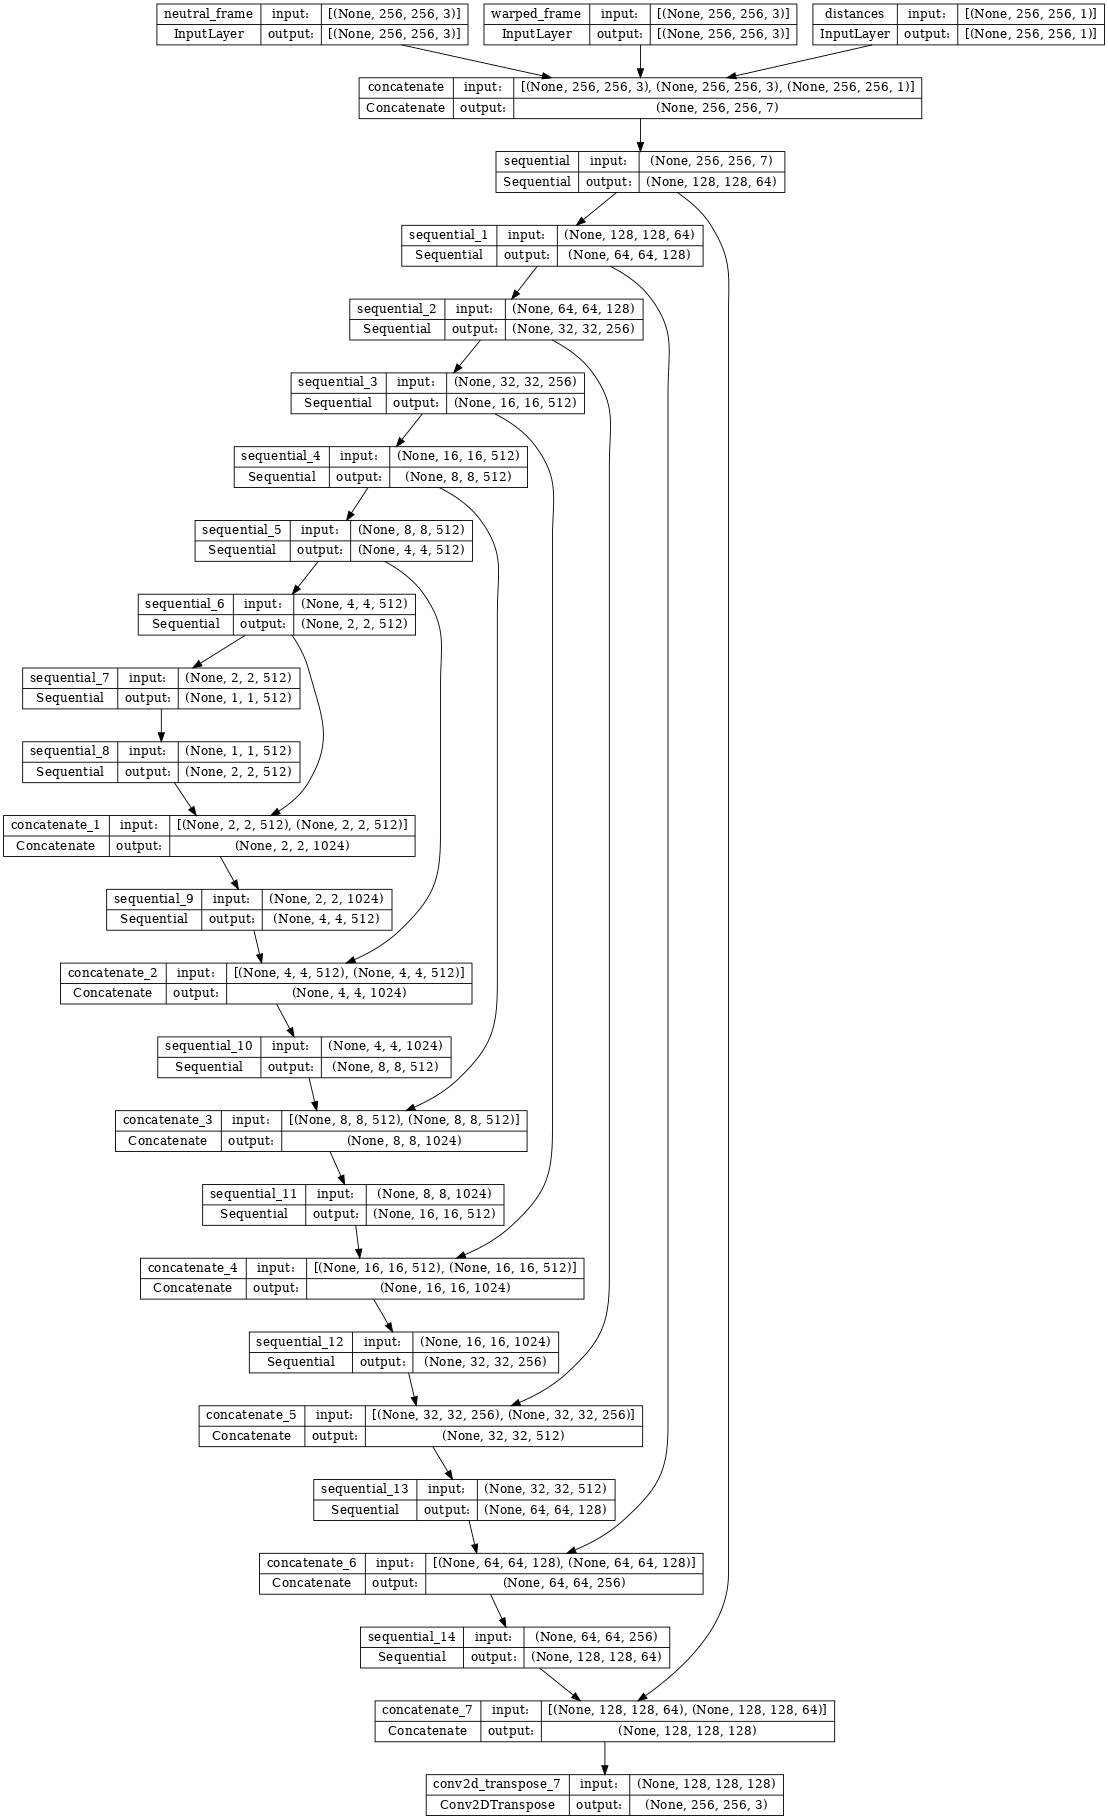

In [10]:
generator = get_generator_model_no_previous(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'generator.png'))

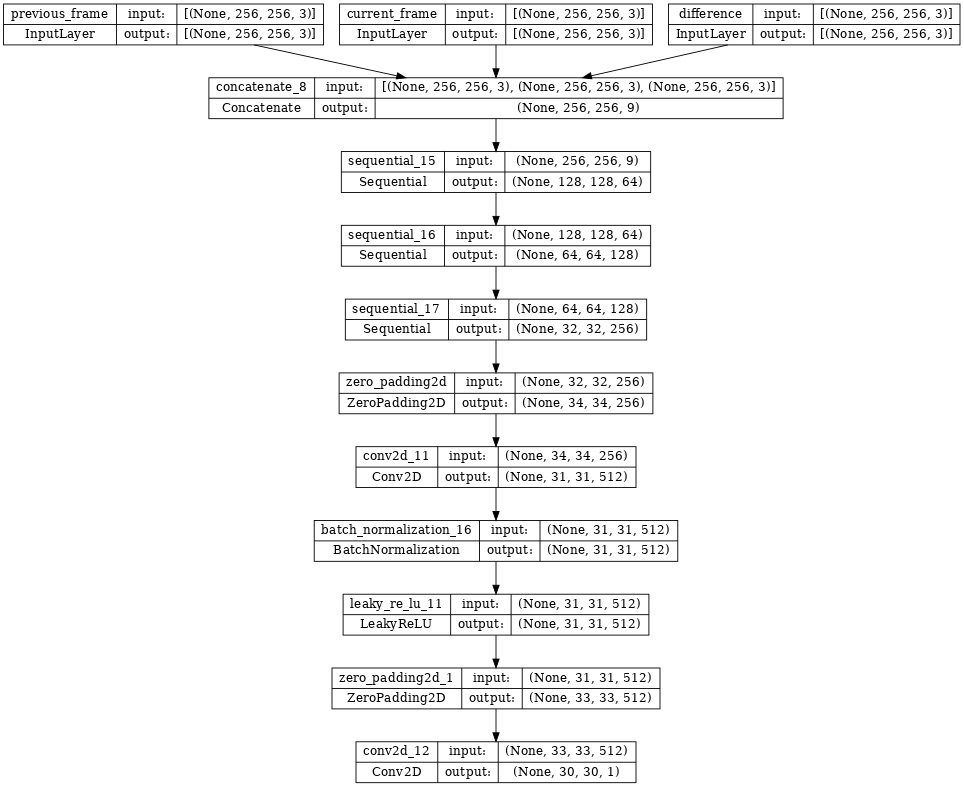

In [11]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file=str(OUTPUT_MEDIA_FOLDER / 'discriminator.png'))

In [12]:
generator_loss = GeneratorLoss(
    # target predicted loss
    target_predicted_function=TARGET_PREDICTED_LOSS,
    lambda_target_predicted=LAMBDA_TARGET_PREDICTED_LOSS,
    # coherence loss
    coherence_loss_function=COHERENCE_LOSS,
    lambda_coherence_loss=LAMBDA_COHERENCE_LOSS,
    # landmarks loss
    landmarks_loss_function=LANDMARKS_LOSS,
    lambda_landmarks_loss=LAMBDA_LANDMARKS_LOSS,
    # landmarks coherence loss
    landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
    lambda_landmarks_coherence_loss=LAMBDA_LANDMARKS_COHERENCE_LOSS,
    # perceptual loss
    lambda_perceptual_loss=LAMBDA_PERCEPTUAL_LOSS,
    # interpolation frames loss
    interpolation_frames_loss_function=INTERPOLATION_FRAMES_LOSS,
    lambda_interpolation_frames_loss=LAMBDA_INTERPOLATION_FRAMES_LOSS,
    # interpolation landmarks loss
    interpolation_landmarks_loss_function=INTERPOLATION_LANDMARKS_LOSS,
    lambda_interpolation_landmarks_loss=LAMBDA_INTERPOLATION_LANDMARKS_LOSS
)
                    

In [13]:
discriminator_loss = DiscriminatorLoss()

In [14]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [15]:
BASE_DIR = OUPUT_PATH / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [16]:
summary_writer = tf.summary.create_file_writer(str(log_file))

In [17]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % DISPLAY_EACH_STEPS == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frames, samples_target = test_dataset_generator.generate_first_batch()
        plot_results(samples_target, previously_generated, generated_frames)

      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_losses = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          for name, value in gen_losses.items():
            tf.summary.scalar(f'gen_{name}', value, step=step)
      
      if (step + 1) % SAVING_EACH_STEPS == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [18]:
if TRAIN:
    tf.profiler.experimental.start(str(log_dir))
    train_generator = PreprocessedDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=True)
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    fit(train_generator, test_generator, steps=STEPS)

## Restore the latest checkpoint and test the network

In [19]:
!ls {checkpoint_dir}

checkpoint		      ckpt-19.data-00000-of-00001
ckpt-1.data-00000-of-00001    ckpt-19.index
ckpt-1.index		      ckpt-190.data-00000-of-00001
ckpt-10.data-00000-of-00001   ckpt-190.index
ckpt-10.index		      ckpt-191.data-00000-of-00001
ckpt-100.data-00000-of-00001  ckpt-191.index
ckpt-100.index		      ckpt-192.data-00000-of-00001
ckpt-101.data-00000-of-00001  ckpt-192.index
ckpt-101.index		      ckpt-193.data-00000-of-00001
ckpt-102.data-00000-of-00001  ckpt-193.index
ckpt-102.index		      ckpt-194.data-00000-of-00001
ckpt-103.data-00000-of-00001  ckpt-194.index
ckpt-103.index		      ckpt-195.data-00000-of-00001
ckpt-104.data-00000-of-00001  ckpt-195.index
ckpt-104.index		      ckpt-196.data-00000-of-00001
ckpt-105.data-00000-of-00001  ckpt-196.index
ckpt-105.index		      ckpt-197.data-00000-of-00001
ckpt-106.data-00000-of-00001  ckpt-197.index
ckpt-106.index		      ckpt-198.data-00000-of-00001
ckpt-107.data-00000-of-00001  ckpt-198.index
ckpt-107.index		      ckpt-199.data-00000-of-0000

In [20]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

Input Sequence


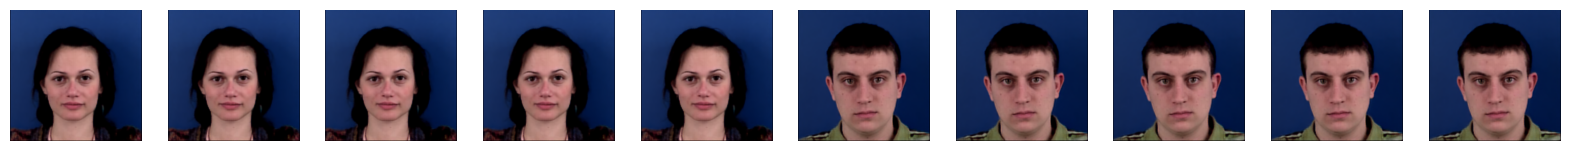

Ground Truth


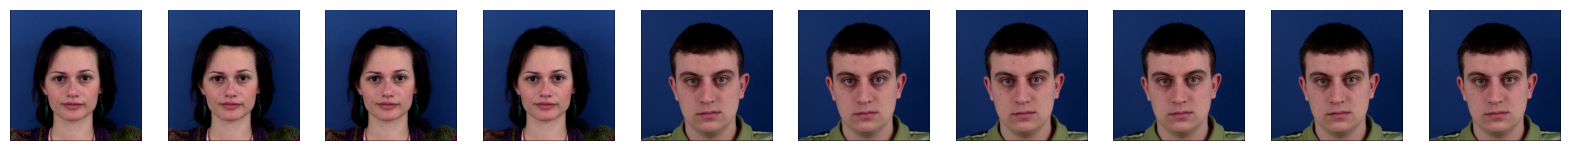

Predicted Sequence


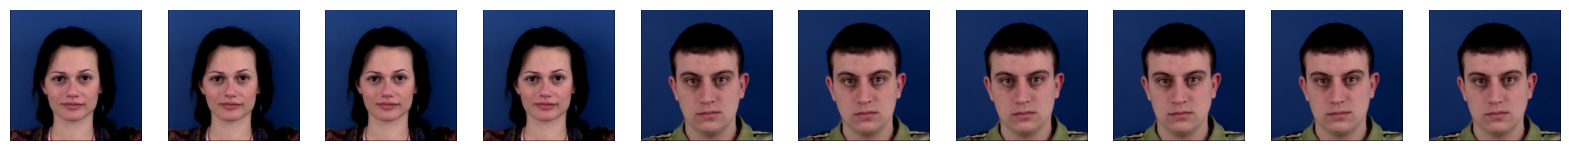

In [21]:
test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
for i in range(0,10):
  previously_generated, generated_frames, samples_target = test_generator.generate_next_batch()
  clear_output(wait=True)
  plot_results(samples_target, previously_generated, generated_frames)

In [22]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [23]:
# evaluating the results with SSIM
def evaluate_metrics(normalized_target_sequence, normalized_generated_output, batch_size):
    target_sequence = images_from_normalized(normalized_target_sequence)
    generated_output = images_from_normalized(normalized_generated_output)
    #cast to float32
    normalized_target_sequence = tf.cast(normalized_target_sequence, tf.float32)
    normalized_generated_output = tf.cast(normalized_generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(target_sequence, generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(target_sequence, generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(normalized_target_sequence, normalized_generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(normalized_target_sequence, normalized_generated_output)
    # compute fid
    # fid_scores = get_frechet_inception_distance(target_sequence, generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(target_sequence, generated_output)
    # compute acd
    acd_scores = compare_acd(target_sequence, generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        # "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }

def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_next_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

In [24]:
if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False)
    scores_path = f"{log_dir}/metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [25]:
if TEST:
    print(df)

In [26]:
if TEST:
    print(df.mean())

In [27]:
if TEST:
    print(df.std())

# coherence measures

In [28]:
def compute_scores():
    scores = []
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                display(pbar.container)
                df = pd.DataFrame(scores)
                df.to_csv(f"{log_dir}/diff_metrics.csv")
                print(df.mean())
                print(df.std())
                _, generated_frames, current_frames = test_generator.generate_diff_batch()
                s = evaluate_metrics(current_frames, generated_frames, batch_size=BATCH_SIZE)
                scores.append(s)
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break
    return scores

if TEST:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
    scores_path = f"{log_dir}/diff_metrics.csv"
    # df = pd.read_csv(scores_path, index_col=0)  
    scores = compute_scores()
    df = pd.DataFrame(scores)
    df.to_csv(scores_path)

In [29]:
if TEST:
    print(df.mean())

In [30]:
if TEST:
    print(df.std())

# Plot some images

In [31]:
if PLOT:
  test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
  for i in range(0,10):
    clear_output(wait=True)
    test_generator.next_plot()

# Save videos gifs

In [ ]:
from data_generator import PreprocessedDataGenerator
if SAVE_GIFS:
    test_generator = PreprocessedDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss, batch_size=BATCH_SIZE, repeat=False, save_path=OUTPUT_MEDIA_FOLDER)
    with tqdm(total=N_TESTING_FRAMES) as pbar:
        while True:
            try:
                clear_output(wait=True)
                test_generator.save_next_video()
                pbar.update(BATCH_SIZE)
            except StopIteration:
                break

  0%|          | 0/42000 [00:00<?, ?it/s]